# 02 · 训练、验证与错误分析

运行本章将下载约 220 MiB 教学数据并进行一次 25 轮训练。数据来自 Laurence Moroney 的合成 Rock Paper Scissors；参考 `docs/03_training/data_and_evaluation.md`。
先明确限制：公开测试成绩不等于真实摄像头成绩。任何后续调参只能参考验证集。

## 1. 导入与固定随机种子

训练实现位于独立模块。每次实验使用新目录，避免覆盖旧权重和报告。

In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "cnn_tutorial").is_dir() and (p / "MAIN.md").exists()), None)
if ROOT is None:
    raise RuntimeError("请从 CNN-Tutorial 项目目录打开此 notebook")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project:", ROOT.name)

import json
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import torch
from cnn_tutorial.data import CLASSES, download_dataset, create_manifest, GestureDataset
from cnn_tutorial.training import TrainConfig, seed_everything, fit, test_checkpoint
DATA = ROOT / "data" / "rps"
RUN = ROOT / "artifacts" / ("rps-" + datetime.now().strftime("%Y%m%d-%H%M%S-%f"))
config = TrainConfig(epochs=25)
seed_everything(config.seed)
print("Classes:", dict(enumerate(CLASSES)))
print("Run:", RUN.relative_to(ROOT))

Project: CNN-Tutorial


Classes: {0: 'paper', 1: 'rock', 2: 'scissors'}
Run: artifacts\rps-20261004-002559-165667


## 2. 下载、验证文件与固定划分

训练/验证来自官方训练池，测试使用官方 test。验证集占训练池 20%，按类别划分。
manifest 包含每张图的路径、类别、split 和 SHA-256。它保证可审计，但随机图片划分不能证明跨人泛化。

In [2]:
downloads = download_dataset(DATA)
manifest = create_manifest(DATA, seed=config.seed)
counts = {split: sum(row["split"] == split for row in manifest["rows"]) for split in ("train", "val", "test")}
print(counts)
assert counts == {"train": 2016, "val": 504, "test": 372}

{'train': 2016, 'val': 504, 'test': 372}


## 3. 先看输入图像

训练前检查类别顺序、灰度转换和缩放结果。这里显示没有增强的训练图；随机增强只在训练 loader 中启用。

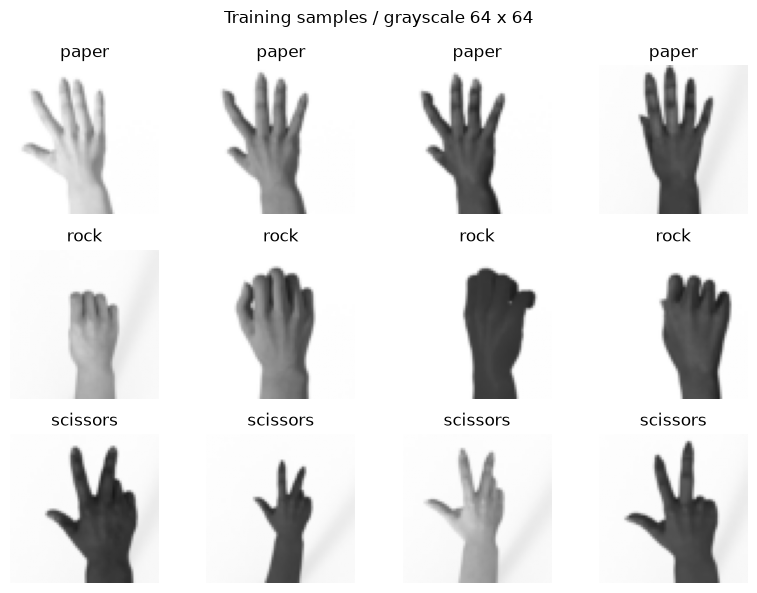

In [3]:
preview = GestureDataset(DATA, "train")
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for label, name in enumerate(CLASSES):
    indices = [i for i, row in enumerate(preview.rows) if row["label"] == label][:4]
    for ax, index in zip(axes[label], indices):
        image, target = preview[index]
        ax.imshow(image[0], cmap="gray", vmin=0, vmax=1)
        ax.set_title(name)
        ax.axis("off")
fig.suptitle("Training samples / grayscale 64 x 64")
fig.tight_layout()
plt.show()

## 4. 阅读一轮训练的核心

每个 batch 做一次参数更新；累计损失要乘 batch 实际大小，避免最后一个小 batch 获得错误权重。
验证不做 optimizer.step。完整 `fit` 根据验证结果保存最佳轮次，并使用余弦调度降低学习率。

In [4]:
import inspect
from cnn_tutorial.training import train_epoch
print(inspect.getsource(train_epoch))

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, count = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = nn.functional.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.numel()
        correct += (logits.argmax(1) == labels).sum().item()
        count += labels.numel()
    return {"loss": total_loss / count, "accuracy": correct / count}



## 5. 开始训练

训练 25 轮并保存验证最优的 best.pt。若验证指标相同，则比较验证损失。
没有把测试集传入训练函数，因此测试不能影响选模。每个 epoch 输出便于查看进展。

In [5]:
model, history, summary = fit(DATA, RUN, config)
print("Best epoch:", summary["best_epoch"])
print("Validation:", summary["validation"]["accuracy"])

epoch 01: train=38.442%, val=40.873%, val_loss=1.0802


epoch 02: train=44.097%, val=62.897%, val_loss=0.9933


epoch 03: train=57.192%, val=78.571%, val_loss=0.7916


epoch 04: train=70.933%, val=79.563%, val_loss=0.6462


epoch 05: train=77.679%, val=89.881%, val_loss=0.4759


...

epoch 22: train=96.974%, val=98.810%, val_loss=0.1035


epoch 23: train=97.222%, val=98.016%, val_loss=0.1063


epoch 24: train=97.024%, val=98.413%, val_loss=0.1049


epoch 25: train=97.173%, val=98.413%, val_loss=0.1046


Best epoch: 22
Validation: 0.9880952380952381


## 6. 查看学习曲线

训练准确率上升而验证停滞，可能提示过拟合或数据分布差异。
训练包含增强，所以训练准确率略低于无增强验证并不一定异常。

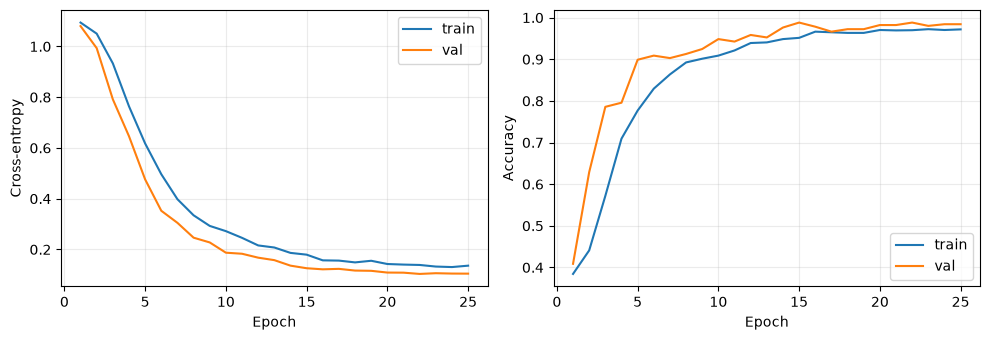

In [6]:
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for split in ("train", "val"):
    axes[0].plot(epochs, [row[f"{split}_loss"] for row in history], label=split)
    axes[1].plot(epochs, [row[f"{split}_accuracy"] for row in history], label=split)
axes[0].set_ylabel("Cross-entropy")
axes[1].set_ylabel("Accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
fig.savefig(RUN / "learning_curves.png", dpi=160)
plt.show()

## 7. 冻结选模后，评估官方测试集

只在方案冻结时运行这一段。类别顺序固定为 paper、rock、scissors。
macro-F1 对各类等权平均；混淆矩阵行表示真实类别，列表示预测类别。对该测试反复观察和调参后，它就不能继续充当新的最终验收集。

{
  "samples": 372,
  "accuracy": 0.8091397849462365,
  "macro_f1": 0.8100021681979565,
  "confusion_matrix": [
    [
      93,
      31,
      0
    ],
    [
      27,
      92,
      5
    ],
    [
      4,
      4,
      116
    ]
  ],
  "per_class": {
    "paper": {
      "precision": 0.75,
      "recall": 0.75,
      "f1": 0.75,
      "support": 124
    },
    "rock": {
      "precision": 0.7244094488188977,
      "recall": 0.7419354838709677,
      "f1": 0.7330677290836655,
      "support": 124
    },
    "scissors": {
      "precision": 0.9586776859504132,
      "recall": 0.9354838709677419,
      "f1": 0.946938775510204,
      "support": 124
    }
  },
  "loss": 0.6702659642824562,
  "checkpoint_sha256": "7e10d57646b1d579ddf45f1b955f558650c877eff0831b9983a9a1d79f8a5b40",
  "scope": "official synthetic RPS test; not camera/subject generalization"
}


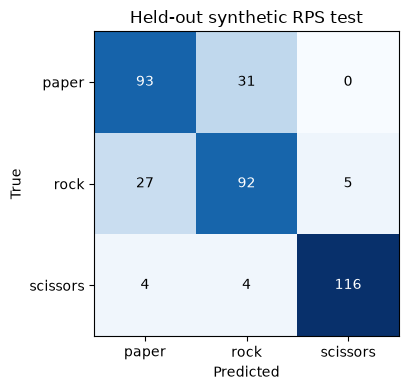

In [7]:
test_metrics = test_checkpoint(DATA, RUN)
print(json.dumps(test_metrics, indent=2))
matrix = np.asarray(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(matrix, cmap="Blues")
ax.set_xticks(range(3), CLASSES)
ax.set_yticks(range(3), CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Held-out synthetic RPS test")
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(matrix[i, j]), ha="center", va="center", color="white" if matrix[i, j] > matrix.max()/2 else "black")
fig.tight_layout()
fig.savefig(RUN / "confusion_matrix.png", dpi=160)
plt.show()

## 8. 只用验证集做下一轮错误分析

检查姿势、灰度、裁剪问题，形成后续实验假设。下面只展示验证集错误。
实际部署前还要新增真实相机测试、无手背景类与分组划分，不能用一张好看的学习曲线替代这些验证。

Validation errors: 6


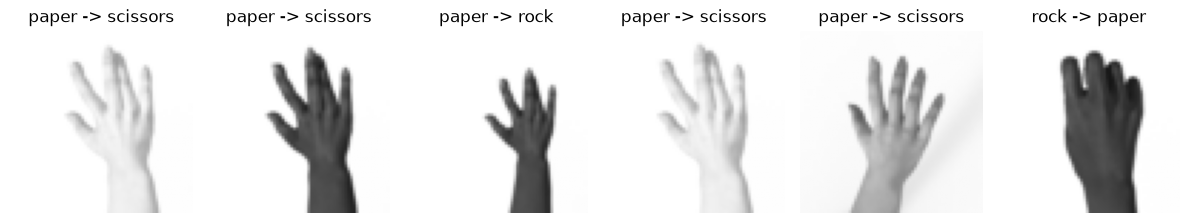

Artifacts: artifacts\rps-20261004-002559-165667


In [8]:
validation = GestureDataset(DATA, "val")
model.eval()
device = next(model.parameters()).device
errors = []
with torch.inference_mode():
    for i in range(len(validation)):
        image, label = validation[i]
        prediction = int(model(image[None].to(device)).argmax(1).item())
        if prediction != label:
            errors.append((image, label, prediction))
print("Validation errors:", len(errors))
if errors:
    fig, axes = plt.subplots(1, min(6, len(errors)), figsize=(12, 2.5), squeeze=False)
    for ax, (image, label, prediction) in zip(axes[0], errors[:6]):
        ax.imshow(image[0], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{CLASSES[label]} -> {CLASSES[prediction]}")
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(RUN / "validation_errors.png", dpi=160)
    plt.show()
print("Artifacts:", RUN.relative_to(ROOT))

## 本章输出与后续

实验目录保留最佳权重、环境/配置、学习曲线、混淆矩阵和指标。
进入优化阶段前，先确认本章步骤与指标。量化路线见 `docs/04_deployment/tinyml_contract.md`，本章还没有产生板卡可运行 INT8 模型。

### 语法与函数速查

- `DataLoader`：按 batch 读取 Dataset；Windows notebook 默认 `num_workers=0`。
- `enumerate`：同时获取索引与值。
- `with torch.inference_mode()`：评估时不记录反向图。
- `state_dict`：参数与缓冲字典，配合模型定义恢复网络。
- `argmax(1)`：沿类别维取最大分数的类别编号。
- `seed`：控制伪随机序列，但不能替代环境与数据版本记录。